<a href="https://colab.research.google.com/github/asinantony/bank-marketing-decision-tree/blob/main/ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Predicting Molecular solubility - ML project**

#**Load Dataset**

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv")
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


# **Data Preparation**

In [ ]:
y=df['logS']

In [ ]:
x=df.drop('logS',axis=1)

#**Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=100)

#**Model Building**

##**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

### **Training Data**

In [ ]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

###**Testing Data**

In [ ]:
y_lr_train_pred=lr.predict(x_train)
y_lr_test_pred=lr.predict(x_test)

###**Evaluating Model Performance**

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
lr_train_mse=mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2=r2_score(y_train,y_lr_train_pred)
lr_test_mse=mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2=r2_score(y_test,y_lr_test_pred)

In [ ]:
lr_results=pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_results.columns=['Model','Training MSE','Training R2','Testing MSE','Testing R2']

In [ ]:
lr_results

,Model,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162


##**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

### **Training Data**

In [ ]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

###**Testing Data**

In [ ]:
y_rf_train_pred=rf.predict(x_train)
y_rf_test_pred=rf.predict(x_test)

###**Evaluating Model Performance**

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
rf_train_mse=mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2=r2_score(y_train,y_rf_train_pred)
rf_test_mse=mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2=r2_score(y_test,y_rf_test_pred)

In [ ]:
rf_results=pd.DataFrame(['Random Forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_results.columns=['Model','Training MSE','Training R2','Testing MSE','Testing R2']
rf_results

,Model,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest,0.082489,0.98072,0.633682,0.869104


#**Model Comparision**

In [ ]:
df_models=pd.concat([lr_results,rf_results],axis=0).reset_index(drop=True)
df_models

,Model,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162
1,Random Forest,0.082489,0.98072,0.633682,0.869104


#**Data Visualization**

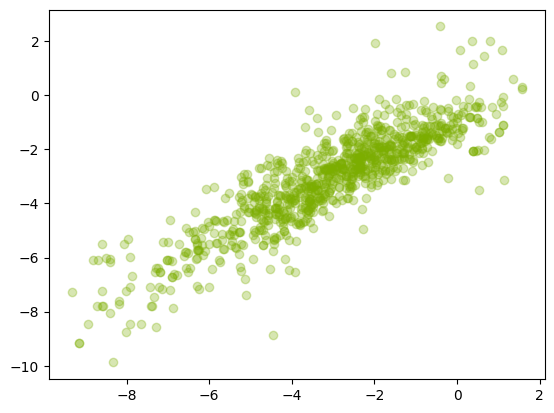

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=y_train,y=y_lr_train_pred,c="#7CAE00",alpha=0.3)
plt.plot()
plt.ylabel=("Predicted Values")
plt.xlabel= ("Real Values")